In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from PIL import Image

In [1]:
RA = 150.0  # http://odahub.io/ontology#PointOfInterestRA
DEC = 20.0  # http://odahub.io/ontology#PointOfInterestDEC
Radius = 5.0  # http://odahub.io/ontology#AngleDegrees ; oda:label "Search Radius (deg)"

In [ ]:
# HYPERPARAMS
SNR_THRESHOLD = 8.0
MAX_DEC_DEG = 75.0
data_path = "data/Tr_380_Flux.csv"
bckg_path = "assets/GalBackgr20MHz-1.jpg"

In [3]:
# Cleaning helper
def _clean_column(series):
  """Convert a column of strings/floats to floats, tolerating stray internal
    whitespace (e.g. "24 .26") that the IDL pipeline accepts but pandas does not."""
  cleaned = series.astype(str).str.replace(r"\s+", "", regex=True)
  return pd.to_numeric(cleaned, errors="coerce")

In [12]:
# Data prep pipeline
COLUMN_NAMES = [
    "time_from_start", "ra", "dec", "dm", "snr",
    "dm_corr", "snr_corr", "tx1000_k", "flux", "flux50"
]

# Load CSV
df = pd.read_csv(data_path, header=0, names=COLUMN_NAMES, skipinitialspace=True, encoding="latin-1")
for col in COLUMN_NAMES:
  df[col] = _clean_column(df[col])

# Convert RA hours to degrees for Astropy calculations
df['ra_deg'] = df['ra'] * 15.0

# Calculate Galactic Coordinates
coords = SkyCoord(ra=df['ra_deg'].values*u.deg, dec=df['dec'].values*u.deg, frame="fk5", equinox="J2000")
df['gl'] = coords.galactic.l.degree
df['gb'] = coords.galactic.b.degree

# Apply standard catalog filters
mask = (df['snr_corr'] > SNR_THRESHOLD) & (df['dec'] < MAX_DEC_DEG)
catalog = df[mask].copy()

# Perform User Cone Search
center_coord = SkyCoord(ra = RA*u.degree, dec = DEC*u.degree)
catalog_coords = SkyCoord(ra=catalog['ra_deg'].values*u.degree, dec=catalog['dec'].values*u.degree)

separations = center_coord.separation(catalog_coords)
cone_mask = separations.deg <= Radius

matches = catalog[cone_mask].copy()
matches['separation_deg'] = separations.deg[cone_mask]

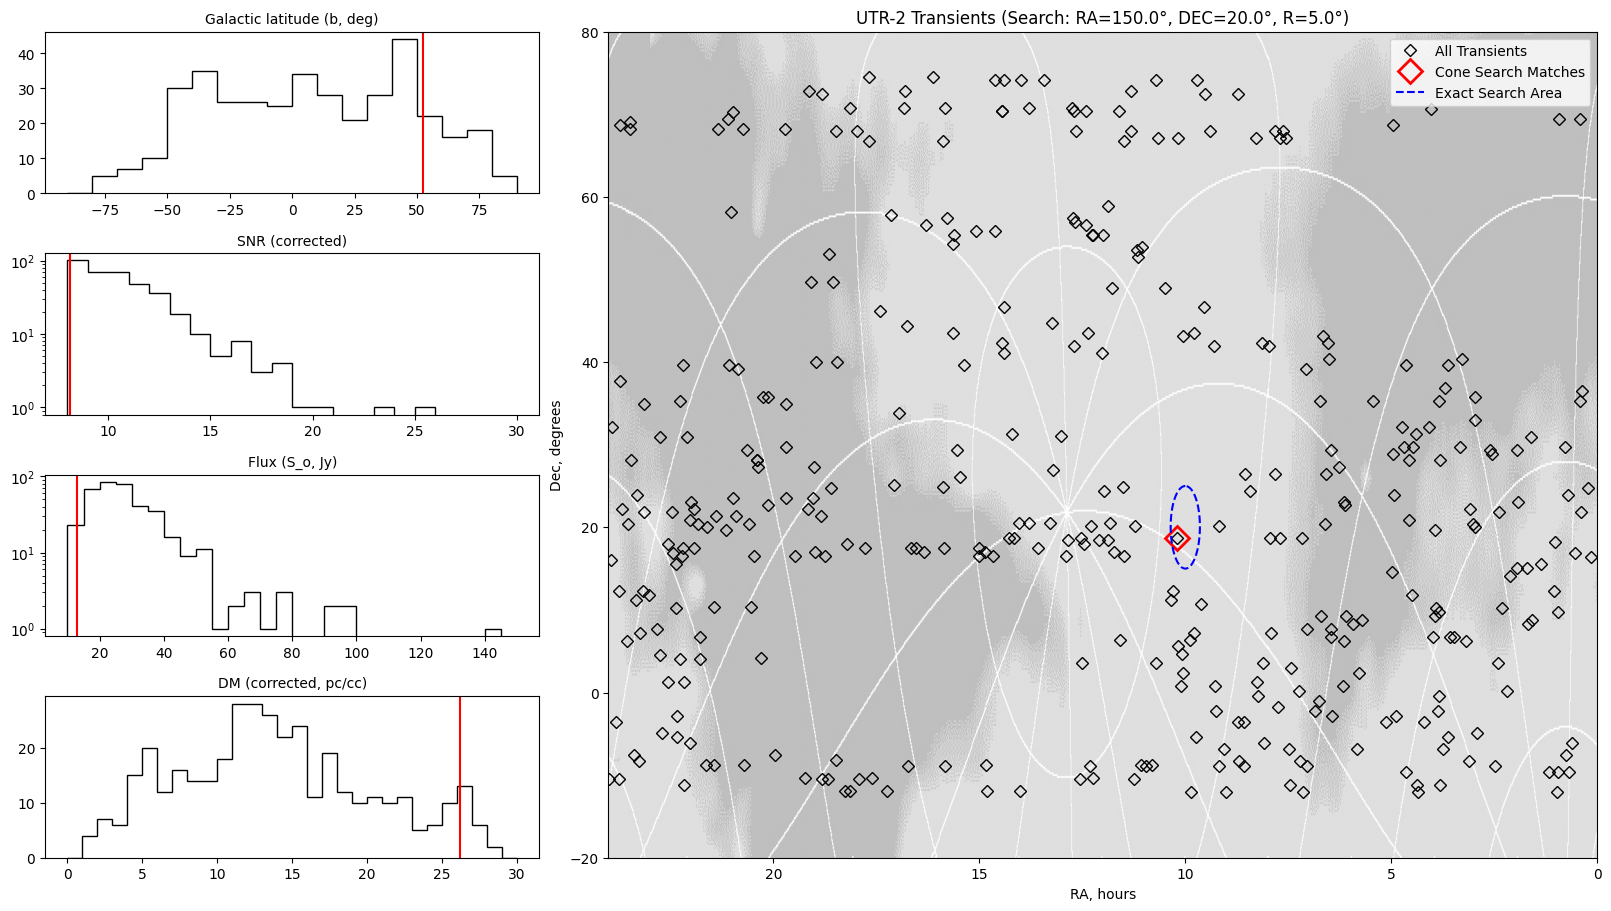

In [14]:
# Plotting pipeline
# Create a large composite figure: Map on right, Histograms on left
fig = plt.figure(figsize=(16, 9), layout="constrained")

# Hists
ax_b = plt.subplot2grid((4, 3), (0, 0))
ax_b.hist(catalog['gb'].dropna(), bins=np.arange(-90, 91, 10), histtype="step", color="black")
ax_b.set_title("Galactic latitude (b, deg)", fontsize=10)

ax_snr = plt.subplot2grid((4, 3), (1, 0))
ax_snr.hist(catalog['snr_corr'].dropna(), bins=np.arange(SNR_THRESHOLD, 31, 1), histtype="step", color="black")
ax_snr.set_yscale("log")
ax_snr.set_title("SNR (corrected)", fontsize=10)

ax_flux = plt.subplot2grid((4, 3), (2, 0))
ax_flux.hist(catalog['flux'].dropna(), bins=np.arange(10, 151, 5), histtype="step", color="black")
ax_flux.set_yscale("log")
ax_flux.set_title("Flux (S_o, Jy)", fontsize=10)

ax_dm = plt.subplot2grid((4, 3), (3, 0))
ax_dm.hist(catalog['dm_corr'].dropna(), bins=np.arange(0, 31, 1), histtype="step", color="black")
ax_dm.set_title("DM (corrected, pc/cc)", fontsize=10)

# MAIN map
ax_map = plt.subplot2grid((4, 3), (0, 1), rowspan=4, colspan=2)

with Image.open(bckg_path) as img:
  arr = np.asarray(img.convert("L"), dtype=np.float32)
  arr = np.clip(arr * 0.5 + 127, 0, 255).astype(np.uint8)

  ax_map.imshow(
    arr,
    extent=(24.0, 0.0, -20.0, 80.0),
    origin="upper",
    aspect="auto",
    cmap="gray",
    vmin=0,
    vmax=255
  )

# Plot all background transients (Black Diamonds)
ax_map.plot(catalog['ra'], catalog['dec'], marker="D", mfc="none", mec="black",
            linestyle="none", markersize=6, label="All Transients")

# Highlight found transients (Red Diamonds)
if not matches.empty:
    ax_map.plot(matches['ra'], matches['dec'], marker="D", mfc="none", mec="red",
                markersize=12, markeredgewidth=2.0, linestyle="none", label="Cone Search Matches")

# User's search cone

angles = np.linspace(0, 360, 100) * u.deg
boundary_coords = center_coord.directional_offset_by(angles, Radius * u.deg)
boundary_ra_hours = boundary_coords.ra.hour
boundary_dec = boundary_coords.dec.degree

ax_map.plot(boundary_ra_hours, boundary_dec, color='blue', linestyle='--',
            linewidth=1.5, label="Exact Search Area")

ax_map.set_xlim(24.0, 0.0)
ax_map.set_ylim(-20.0, 80.0)
ax_map.set_xlabel("RA, hours")
ax_map.set_ylabel("Dec, degrees")
ax_map.set_title(f"UTR-2 Transients (Search: RA={RA}°, DEC={DEC}°, R={Radius}°)")
ax_map.legend(loc="upper right")

# Hist markers
# Draw red vertical lines on histograms for the matching transients
for _, match in matches.iterrows():
  ax_b.axvline(match['gb'], color="red", linewidth=1.5)
  ax_snr.axvline(match['snr_corr'], color="red", linewidth=1.5)
  ax_flux.axvline(match['flux'], color="red", linewidth=1.5)
  ax_dm.axvline(match['dm_corr'], color="red", linewidth=1.5)

plot_filename = 'utr2_transient_analysis.jpeg'
plt.savefig(plot_filename, dpi=300, bbox_inches="tight")

In [ ]:
from oda_api.data_products import PictureProduct, ODAAstropyTable
from astropy.table import Table

# The Image File
bin_image = PictureProduct.from_file(plot_filename)

if matches.empty:
  # Return empty table if nothing found
  spec = ODAAstropyTable(Table(names = COLUMN_NAMES))
else:
  astropy_tbl = Table.from_pandas(matches)
  spec = ODAAstropyTable(astropy_tbl)

# Final Ontology bindings
transient_map = bin_image # http://odahub.io/ontology#ODAPictureProduct
transient_table = spec # http://odahub.io/ontology#ODAAstropyTable